In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.pendulum import PendulumIntraTrajectoryGLSConfig, run_pendulum_intra_trajectory_gls_experiment
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = PendulumIntraTrajectoryGLSConfig(
    n_runs=5,
    t0=0.0,
    t1=10.0,
    dt=1e-3,
    g=9.81,
    L=1.0,
    c=0.5,
    sigma0=0.0,
    alpha=0.25,
    poly_degree=1,
    derivative_order=1,
    H_xt=0.1,
    K=500,
    p=2,
    include_bias=False,
    stlsq_threshold=0.05,
    n_ensemble_models=100,
    seed_base=0,
    results_dir="results",
    results_filename="pendulum_weighted_errors.csv",
)


# Pendulum Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

The damped linear pendulum is governed by

$$
\begin{aligned}
\dot{\theta} &= \omega, \\
\dot{\omega} &= -\frac{g}{\ell}\theta - c\,\omega,
\end{aligned}
$$

where \(\theta\) denotes the angular displacement, \(\omega\) the angular velocity, \(g\) the gravitational acceleration, \(\ell\) the pendulum length, and \(c\) the damping coefficient.

In all simulations, we set
$$
g=1, \qquad \ell=1, \qquad c=0.5.
$$

Let $U = (\theta,\omega)^\top$ denote the system state. We model additive perturbation error by adding a zero-mean random noise term \(\epsilon\) to \(U\), so that
$$
U^{\mathrm{noisy}} = U + \epsilon.
$$

The perturbation is assumed to satisfy
$$
\mathbb{E}[\epsilon] = 0,
\qquad
\mathrm{Var}(\epsilon) \propto \alpha^2 \|U\|^2,
$$
where \(\alpha > 0\) controls the noise amplitude.

## Trajectories

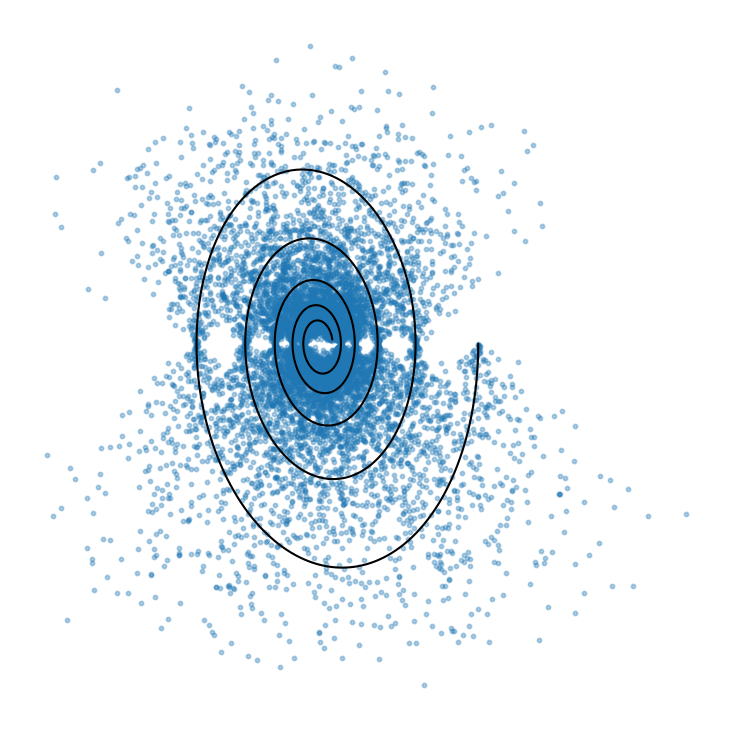

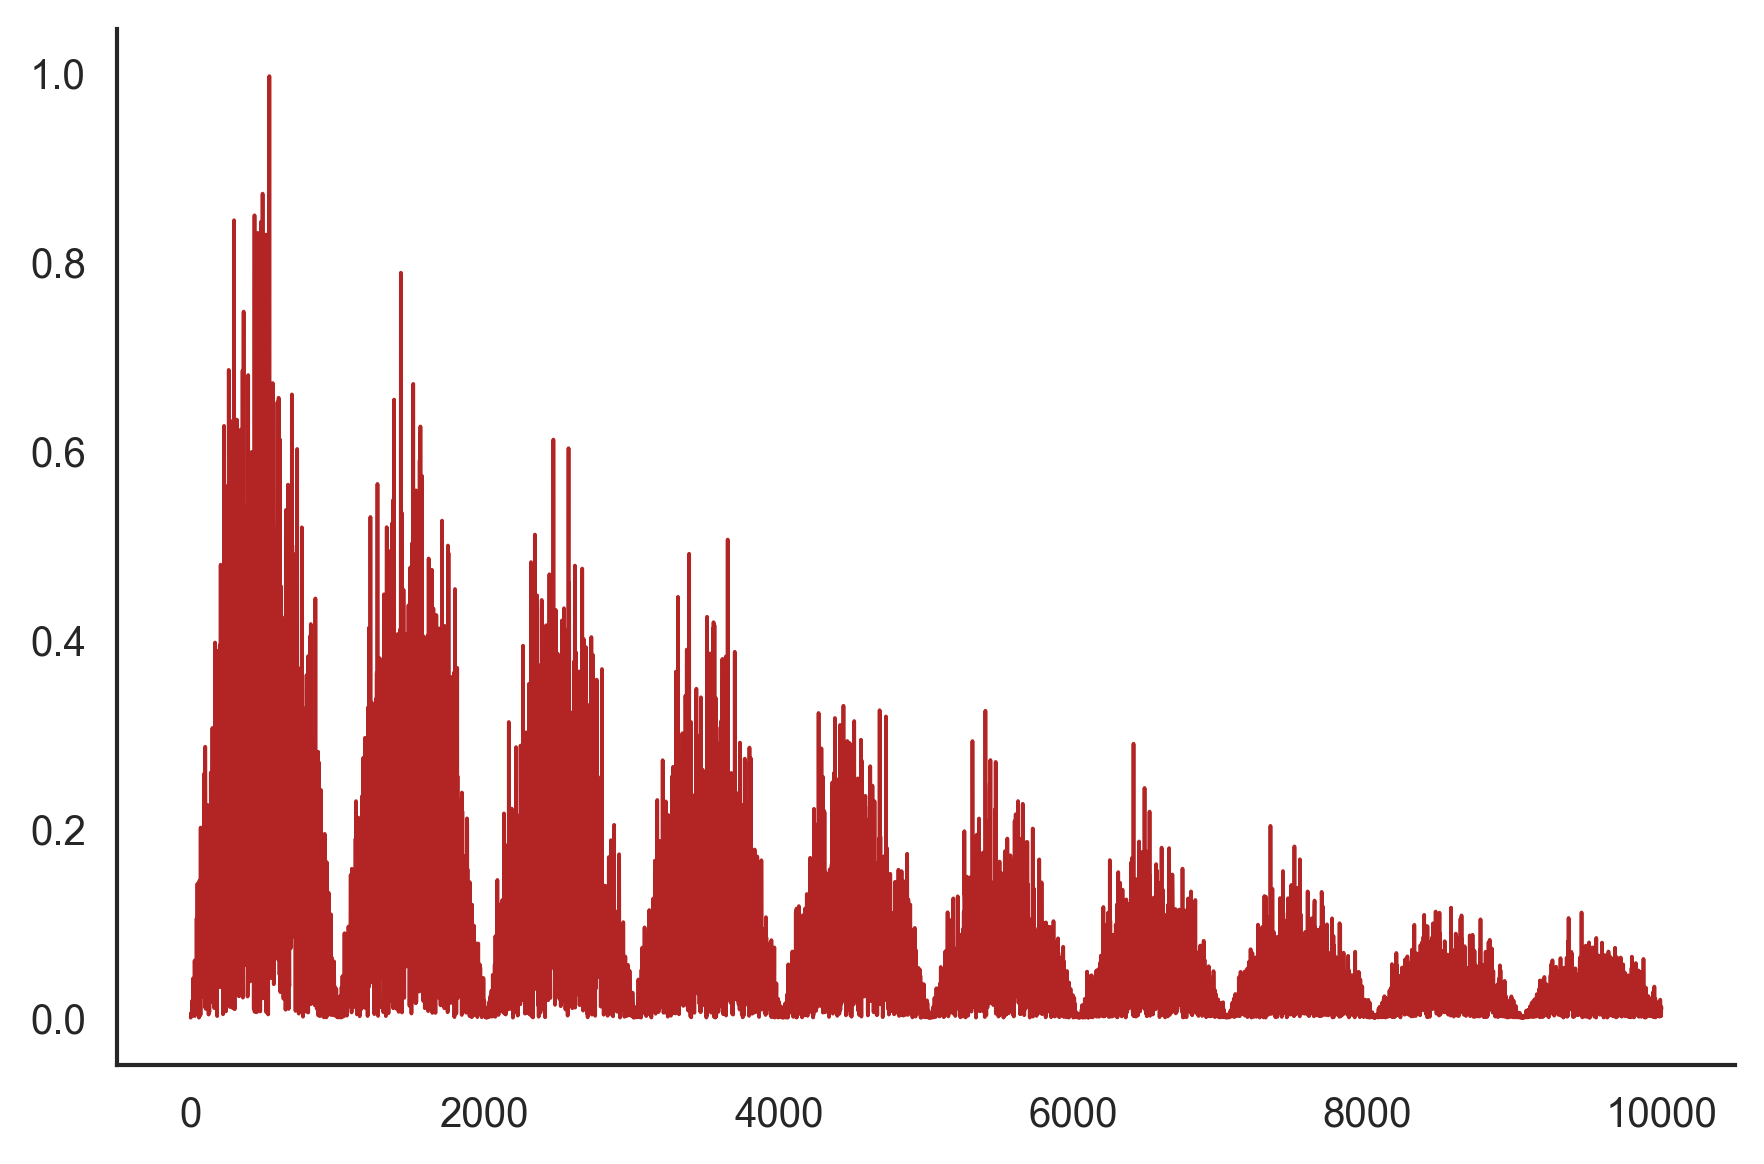

In [2]:
from mfsindy.cases.pendulum import simulate_pendulum_trajectory
from mfsindy.cases.pendulum_plots import plot_trajectories_additive_noise, plot_residuals

y0 = np.array([0.5, 0.0])
t_eval, Y_true = simulate_pendulum_trajectory(
    y0=y0,
    T=cfg.t1 - cfg.t0,
    dt=cfg.dt,
    g=cfg.g,
    L=cfg.L,
    c=cfg.c,
    noise_level=0.0,
    seed=0,
)
Y_noisy = plot_trajectories_additive_noise(
    x_true=Y_true,
    alpha=cfg.alpha,
    sigma0=cfg.sigma0,
)
plot_residuals(Y_true, Y_noisy)


In [3]:
print(f"Running heteroscedastic pendulum GLS experiment with {cfg.n_runs} runs.")

df_errors, L1_errors_in_mem, L0_errors_in_mem = run_pendulum_intra_trajectory_gls_experiment(cfg)


Running heteroscedastic pendulum GLS experiment with 5 runs.


Monte Carlo pendulum GLS: 100%|██████████| 5/5 [00:07<00:00,  1.46s/it]


## Run

In [4]:
errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

methods = ["No weighting", "Variance GLS", "Ones GLS"]

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nMedian L1 errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L1_errors[m]):.3e}")

print("\nMedian L0 support errors (reloaded from CSV):")
for m in methods:
    print(f"{m:14s} : {np.median(L0_errors[m]):.3e}")



Median L1 errors (reloaded from CSV):
No weighting   : 1.247e-02
Variance GLS   : 5.781e-03
Ones GLS       : 6.636e-03

Median L0 support errors (reloaded from CSV):
No weighting   : 0.000e+00
Variance GLS   : 0.000e+00
Ones GLS       : 0.000e+00


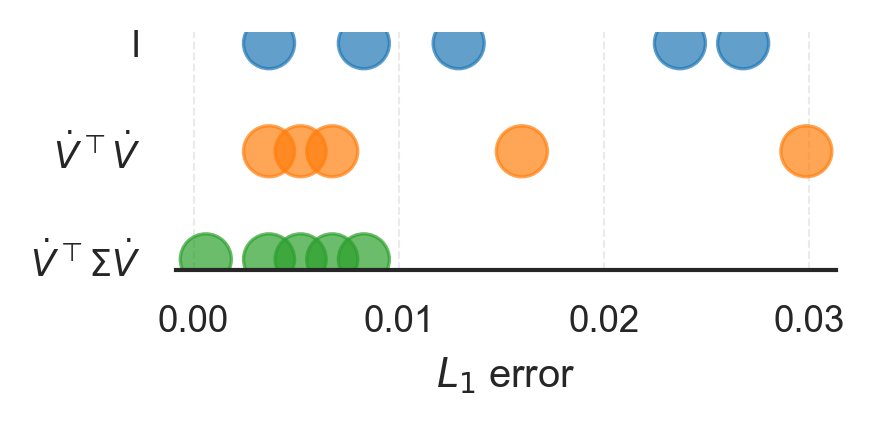

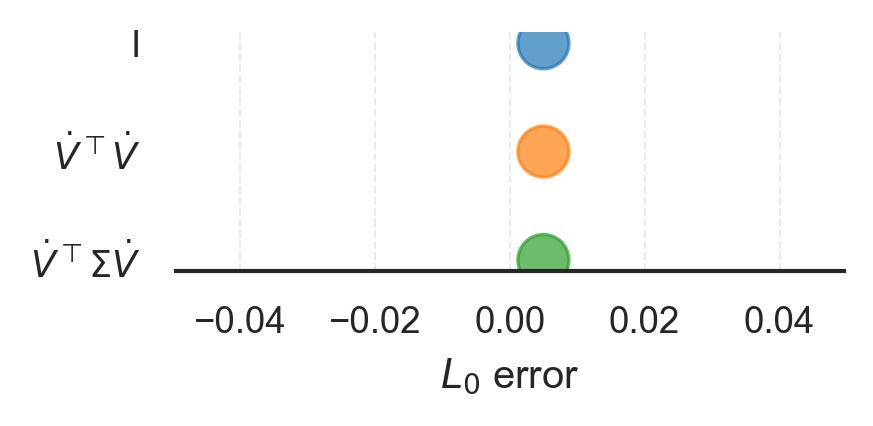

In [5]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}^\top\Sigma\dot{V}$",r"$\dot{V}^\top\dot{V}$","I"]

bubble_hist(
    errors_dict=L1_errors,
    xlabel=r"$L_1$ error",
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels
)

bubble_hist(
    errors_dict=L0_errors,
    xlabel=r"$L_0$ error",
    n_bins=10,
    models_order=methods,
    colors=method_colors,
    labels=labels
)


## Error Plots